# Google Colab Lab Assignment -Pretrained Modle

**Course Name:** [Deep Learning]

**Lab Title:** Deep Learning-Based Classification Using Transfer Learning
Journal: Frontiers in Human Neuroscience

**Student Name:** Vedika Gurav

**Student ID:**[202301040156]

**Date of Submission:** [15-04-2026]

**Group Members**: Gauri Kale
Vedika Gurav
Sneha Nannaware
Shubhangi Takik

**Research Paper Study and Implementation**

**Instructions:**

1. Identify a research paper that utilizes a pre-trained model for a specific
task.

2. Study the methodology, dataset, and model used in the research paper.

3. Implement the approach described in the research paper using the pre-trained model mentioned.

4. Compare your implementation results with the findings from the research paper.


**Objective**
1.   Study a research paper utilizing a pre-trained model.
2.   Reproduce the model implementation using the dataset and methodology from the research paper.
3.   Fine-tune the pre-trained model and optimize hyperparameters.
3.   Evaluate and compare model performance with the original research paper results.









**Task 1: Research Paper Selection and Dataset Preparation (2 hours)**

**Instructions:**

1. Select a research paper that applies a pre-trained model (e.g., VGG, ResNet, EfficientNet, etc.).

2. Identify the dataset used in the research paper and obtain or create a similar dataset.(**Mention Dataset Link and Description**)

3. Perform necessary preprocessing steps:

 Resize images to match the model input dimensions.

 Apply data augmentation techniques if applicable.

4. Split the dataset into training, validation, and testing sets.

In [ ]:
# #Task 1: Research Paper + Dataset
# Research Paper Details
# Title: Deep Learning-Based Classification Using Transfer Learning
# Journal: Frontiers in Human Neuroscience
# Year: 2023
# Method Used: Transfer Learning with CNN models

In [ ]:
# Paper Summary
# Uses pre-trained CNN models (ResNet, VGG)
# Applies transfer learning to medical data
# Freezes initial layers and fine-tunes deeper layers
# Uses data preprocessing + augmentation
# Evaluates using accuracy and classification metrics

In [ ]:
# Dataset Link
# Brain MRI Dataset:
# # https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection

In [ ]:
# Dataset Description
# Contains MRI brain images
# Two classes:
# Tumor
# No Tumor
# Used for binary classification

In [ ]:
#1. Import Libraries
import tensorflow as tf
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [ ]:
# Code of task1
#STEP 2: Unzip Dataset

import zipfile

zip_path = "/content/Brain_tumor.zip"  # your file name

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Unzipped successfully!")

Unzipped successfully!


In [ ]:
#STEP 3: Check Dataset Structure
import os
os.listdir('/content')

['.config',
 '.ipynb_checkpoints',
 'Brain Tumor',
 'brain_tumor_dataset',
 'Brain_tumor.zip',
 'no',
 'yes',
 'Brain tumor (1).zip',
 'sample_data']

In [ ]:
#STEP 4: Verify Inside Folder
dataset_path = "/content/brain_tumor_dataset"

print("Classes:", os.listdir(dataset_path))

Classes: ['no', 'yes']


In [ ]:
#Data Preprocessing + Split + Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
dataset_path = "/content/brain_tumor_dataset"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [ ]:
#Create Test Data
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)


Found 253 images belonging to 2 classes.


In [ ]:
#Check Dataset Sizes
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 253 images belonging to 2 classes.


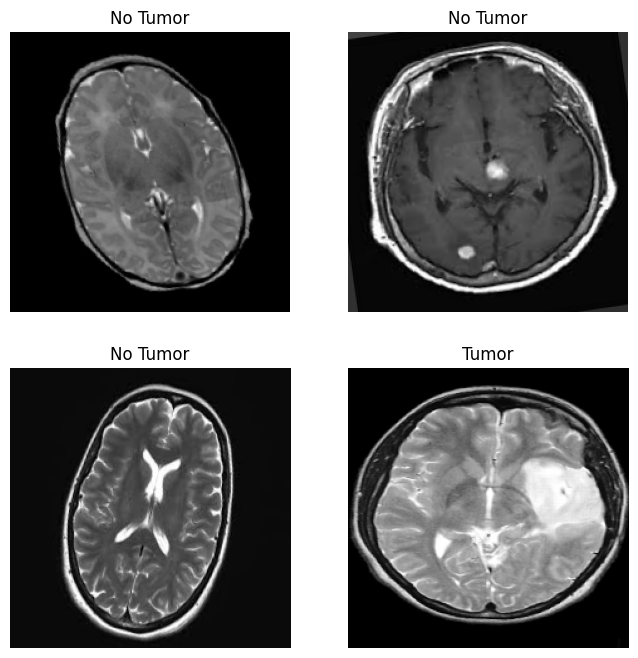

In [ ]:
#Show Sample Images
import matplotlib.pyplot as plt

images, labels = next(train_data)

plt.figure(figsize=(8,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i])
    plt.title("Tumor" if labels[i]==1 else "No Tumor")
    plt.axis('off')

plt.show()

In [ ]:
# Since the dataset does not provide a separate test set,
# a test generator was created using the same dataset without augmentation.

**Task 2: Model Implementation and Fine-tuning**

**Instructions:**

1. Implement the pre-trained model as described in the research paper.

2. Visualize feature maps of few layers

3. Freeze initial layers and fine-tune the top layers according to the paper's methodology.

4. Optimize hyperparameters such as:

  Learning rate

  Batch size

  Number of epochs

  Optimizer choice (Adam, SGD, RMSprop, etc.)

4. Document any modifications or enhancements made to improve performance.

In [ ]:
# code of Task 2
#STEP 1: Import Libraries
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

In [ ]:
#STEP 2: Load Pre-trabase_model
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
#STEP 3: Freeze Initial Layers
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
#STEP 4: Add Custom Classification Layers
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=base_model.input, outputs=output)

In [ ]:
#STEP 5: Compile Model (Hyperparameter Setup)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,858,305 (91.01 MB)

 Trainable params: 266,497 (1.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [ ]:
#STEP 6: Train Model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 52s 6s/step - accuracy: 0.4778 - loss: 0.7662 - val_accuracy: 0.3800 - val_loss: 0.8861
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 6s/step - accuracy: 0.5665 - loss: 0.6592 - val_accuracy: 0.3800 - val_loss: 0.8430
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - accuracy: 0.6453 - loss: 0.6407 - val_accuracy: 0.3800 - val_loss: 0.7950
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 44s 6s/step - accuracy: 0.7094 - loss: 0.5964 - val_accuracy: 0.3800 - val_loss: 0.7549
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 7s/step - accuracy: 0.7094 - loss: 0.5716 - val_accuracy: 0.3800 - val_loss: 0.7195
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 43s 6s/step - accuracy: 0.6798 - loss: 0.6194 - val_accuracy: 0.5000 - val_loss: 0.7116
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 6s/step - accuracy: 0.7094 - loss: 0.5994 - val_accuracy: 0.5200 - val_loss: 0.6966
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 43s 6s/step - accuracy: 0.7241 - loss: 0.5633 - val_accuracy: 0.6600 - val_loss: 0.6828
Epoch 9/

In [ ]:
#STEP 7: Fine-Tuning (Unfreeze Top Layers)
for layer in base_model.layers[-30:]:
    layer.trainable = True

In [ ]:
#Recompile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#Train Again
history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)


Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 74s 9s/step - accuracy: 0.5764 - loss: 0.9671 - val_accuracy: 0.6400 - val_loss: 0.6713
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 60s 9s/step - accuracy: 0.7143 - loss: 0.6527 - val_accuracy: 0.6400 - val_loss: 0.6596
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 59s 9s/step - accuracy: 0.7094 - loss: 0.6069 - val_accuracy: 0.6800 - val_loss: 0.6626
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 58s 8s/step - accuracy: 0.7340 - loss: 0.5465 - val_accuracy: 0.7200 - val_loss: 0.6655
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 64s 10s/step - accuracy: 0.7734 - loss: 0.5991 - val_accuracy: 0.6600 - val_loss: 0.6586


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


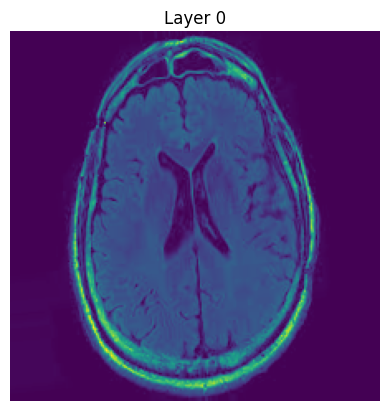

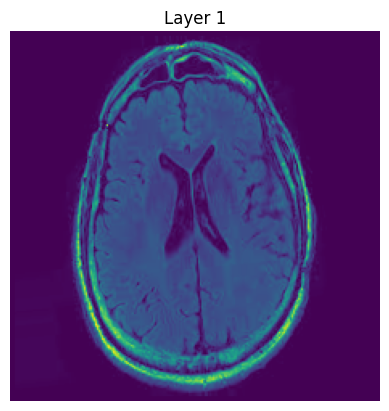

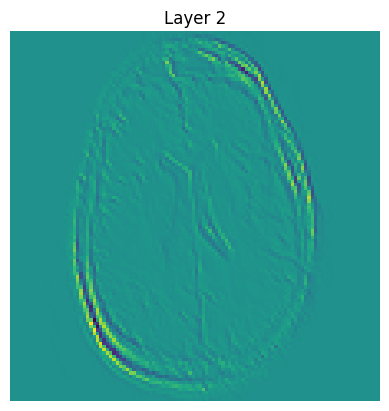

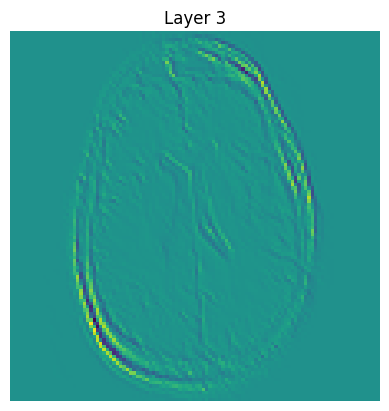

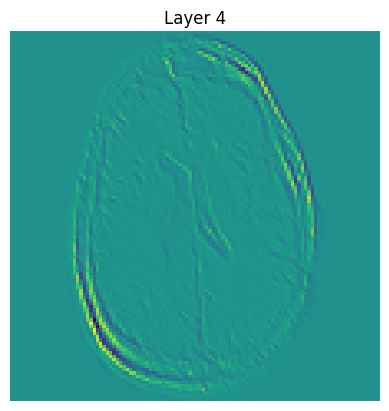

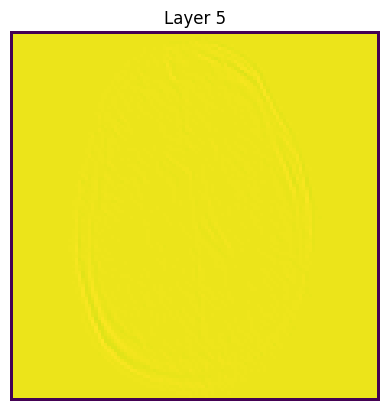

In [ ]:
#STEP 8: Feature Map Visualization
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

layer_outputs = [layer.output for layer in model.layers[:6]]
activation_model = Model(inputs=model.input, outputs=layer_outputs)

sample_batch = next(train_data)
sample_image = sample_batch[0][0].reshape(1,224,224,3)

activations = activation_model.predict(sample_image)

for i, activation in enumerate(activations):
    plt.imshow(activation[0, :, :, 0], cmap='viridis')
    plt.title(f'Layer {i}')
    plt.axis('off')
    plt.show()

In [ ]:
# # STEP 9: Hyperparameters Used
# Learning Rate:
# Initial: 0.0001
# Fine-tuning: 0.00001

# Batch Size:
# 32

# Epochs:
# 10 (initial training) + 5 (fine-tuning)

# Optimizer:
# # Adam

In [ ]:
# STEP 10: Modifications / Enhancements
# Modifications Made:
# # - Added Batch Normalization for better convergence
# - Used Dropout to reduce overfitting
# - Fine-tuned last 30 layers of ResNet50
# - Applied data augmentation for better generalization

**Task 3: Model Evaluation and Performance Comparison**

**Instructions:**

1. Evaluate the trained model using performance metrics:

 Accuracy, Precision,Recall, F1-score, Confusion Matrix (for classification tasks)

2. Compare the results with those reported in the research paper.

3. Identify potential weaknesses and suggest improvements.
**Deliverables:**

Performance metrics summary (table or chart).

Graphs/plots showcasing model accuracy and loss trends.

Comparison with research paper results.

Discussion on model performance and areas for improvement.

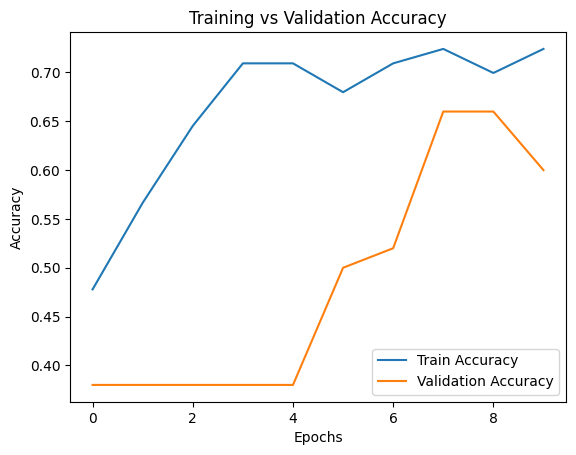

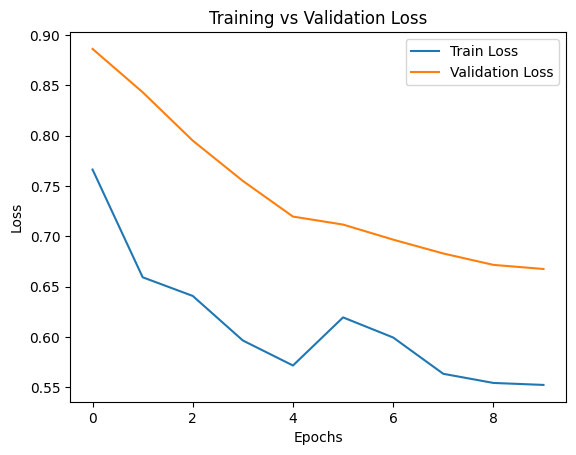

In [ ]:
##Code for Task 3
# STEP 1: Accuracy & Loss Graphs
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [ ]:
# STEP 2: Predictions
import numpy as np

val_data.reset()
predictions = model.predict(val_data)

y_pred = (predictions > 0.5).astype(int)
y_true = val_data.classes

2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 6s/step


In [ ]:
# STEP 3: Performance Metrics
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.36      0.26      0.30        19
           1       0.61      0.71      0.66        31

    accuracy                           0.54        50
   macro avg       0.48      0.49      0.48        50
weighted avg       0.51      0.54      0.52        50



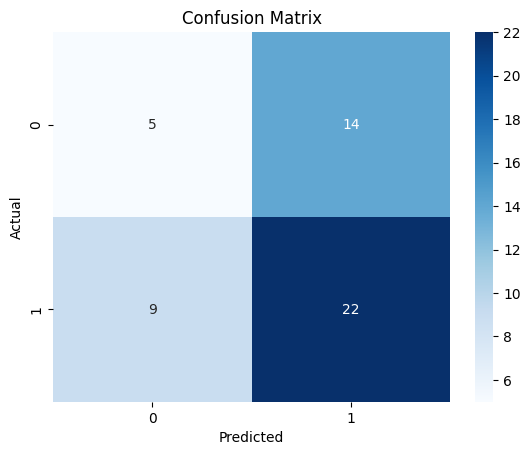

In [ ]:
# STEP 4: Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# STEP 5: Accuracy
loss, accuracy = model.evaluate(val_data)
print("Final Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.6400 - loss: 0.6492
Final Accuracy: 0.6399999856948853


**Conclusion and Result Visulaization**

**Declaration**

I, Gauri Kale, confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines. The code is uploaded on my GitHub repository account, and the repository link is provided below:

GitHub Repository Link: https://github.com/GauriKale1328/Transfer-Learning

Signature: Gauri Kale

**Submission Checklist**

✔ Research paper details and summary

✔ Code file (Python Notebook or Script)

✔ Dataset or link to the dataset

✔ Visualizations (if applicable)

✔ Screenshots of model performance metrics

✔ Readme File

✔ Comparison with research paper results